<a href="https://colab.research.google.com/github/stephanyborzi/DataScienceClasses/blob/main/TreinamentoSucessoVendasKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [325]:
#Engenharia de Software

#Stephany Borzi Marques RM 557351
#Guilherme Barreto Mendes RM557916
#Arthur Galvão Alves RM554462
#Erick Moreira Fujita RM556096

In [326]:
import pandas as pd
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV


In [327]:
df = pd.read_excel('/content/Base_Previsao_Sucesso_Vendas.xlsx')
df

,Cliente_ID,Idade,Regiao_Destino,Renda_Mensal,Historico_Compras_Cliente,Canal_Venda,Categoria_Vinho,Valor_Total_Pedido,Tempo_Entrega_Estimado_Dias,Desconto_Aplicado_Percentual,Disponibilidade_Estoque,Sucesso_Venda
0,CLI_052,66,Jardins,11305.98,8,WhatsApp,Tinto Encorpado,89.9,1,0,Pronta Entrega,1
1,CLI_022,64,Santana,8488.79,8,E-commerce,Tinto Encorpado,171.0,2,0,Pronta Entrega,0
2,CLI_014,70,Itaim Bibi,21789.76,6,E-commerce,Tinto Encorpado,89.0,1,0,Pronta Entrega,0
3,CLI_044,75,Jardins,21874.58,11,E-commerce,Tinto Encorpado,285.0,1,10,Sob Encomenda,1
4,CLI_029,75,Jardins,19325.05,9,E-commerce,Tinto Encorpado,179.8,1,5,Pronta Entrega,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,CLI_035,72,Tatuapé,12558.44,2,Televendas,Espumante Leve,NaN,5,0,Pronta Entrega,0
996,CLI_014,70,Itaim Bibi,21789.76,1,WhatsApp,Tinto Médio,105.0,3,0,Pronta Entrega,1
997,CLI_041,24,Itaim Bibi,20005.79,4,Loja Física,Tinto Encorpado,269.7,1,5,Pronta Entrega,1
998,CLI_045,42,Moema,16973.48,2,E-commerce,Tinto Ultra Premium,NaN,2,5,Pronta Entrega,1


## Exploração dos Dados







In [328]:
df.sample(10)

,Cliente_ID,Idade,Regiao_Destino,Renda_Mensal,Historico_Compras_Cliente,Canal_Venda,Categoria_Vinho,Valor_Total_Pedido,Tempo_Entrega_Estimado_Dias,Desconto_Aplicado_Percentual,Disponibilidade_Estoque,Sucesso_Venda
0,CLI_052,66,Jardins,11305.98,8,WhatsApp,Tinto Encorpado,89.9,1,0,Pronta Entrega,1
852,CLI_080,29,Vila Mariana,15741.98,14,WhatsApp,Tinto Encorpado,89.0,2,15,Últimas Unidades,1
169,CLI_067,33,Tatuapé,9545.83,5,Loja Física,Tinto Médio,NaN,4,0,Pronta Entrega,0
727,CLI_025,18,Jardins,10497.29,3,E-commerce,Branco Leve,139.8,1,0,Pronta Entrega,0
430,CLI_011,74,Jardins,13396.03,6,E-commerce,Tinto Ultra Premium,420.0,1,0,Pronta Entrega,1
676,CLI_066,59,Itaim Bibi,12226.07,4,Marketplace,Branco Leve,139.8,1,0,Últimas Unidades,0
491,CLI_069,29,Vila Mariana,10632.64,3,Loja Física,Tinto Encorpado,NaN,3,10,Últimas Unidades,0
253,CLI_056,61,Moema,NaN,2,E-commerce,Tinto Encorpado,89.9,2,15,Pronta Entrega,1
584,CLI_078,37,Moema,13478.29,2,Marketplace,Branco Aromático,588.0,2,5,Sob Encomenda,0
683,CLI_024,46,Tatuapé,8582.25,1,WhatsApp,Tinto Encorpado,125.0,3,5,Pronta Entrega,0


In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Cliente_ID                    1000 non-null   object 
 1   Idade                         1000 non-null   int64  
 2   Regiao_Destino                1000 non-null   object 
 3   Renda_Mensal                  972 non-null    float64
 4   Historico_Compras_Cliente     1000 non-null   int64  
 5   Canal_Venda                   1000 non-null   object 
 6   Categoria_Vinho               1000 non-null   object 
 7   Valor_Total_Pedido            632 non-null    float64
 8   Tempo_Entrega_Estimado_Dias   1000 non-null   int64  
 9   Desconto_Aplicado_Percentual  1000 non-null   int64  
 10  Disponibilidade_Estoque       1000 non-null   object 
 11  Sucesso_Venda                 1000 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB


In [330]:
df.describe()

,Idade,Renda_Mensal,Historico_Compras_Cliente,Valor_Total_Pedido,Tempo_Entrega_Estimado_Dias,Desconto_Aplicado_Percentual,Sucesso_Venda
count,1000.000000,972.000000,1000.000000,632.000000,1000.000000,1000.000000,1000.000000
mean,47.055000,14112.313488,4.676000,360.047152,2.152000,4.935000,0.658000
std,17.169647,5132.471673,3.696849,417.872886,1.040182,6.108034,0.474617
min,18.000000,6373.230000,0.000000,69.900000,1.000000,0.000000,0.000000
25%,33.000000,9545.830000,2.000000,139.800000,1.000000,0.000000,0.000000
50%,49.000000,12939.520000,4.000000,250.000000,2.000000,5.000000,1.000000
75%,61.000000,18388.310000,7.000000,420.000000,3.000000,10.000000,1.000000
max,75.000000,27852.970000,20.000000,5040.000000,5.000000,20.000000,1.000000


<Axes: >

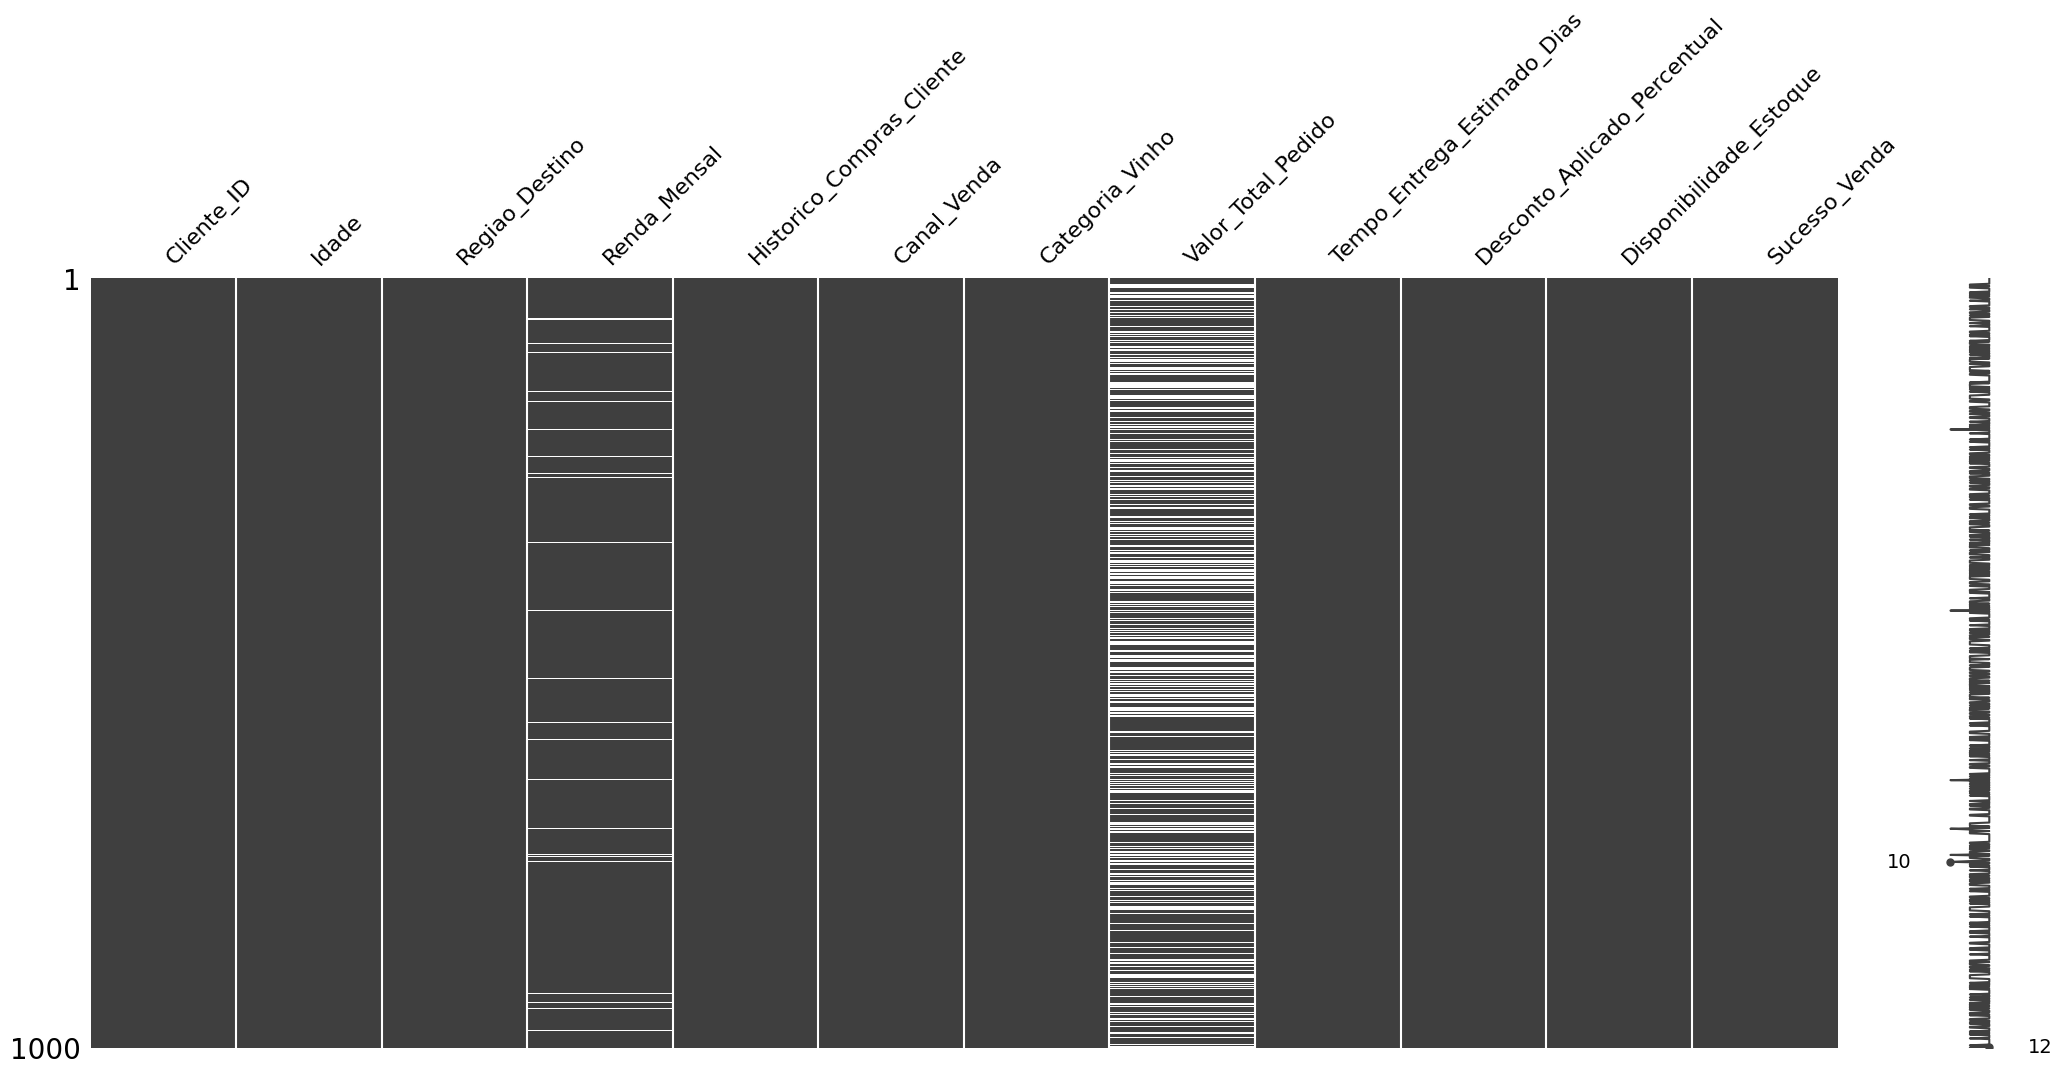

In [331]:
msno.matrix(df)

### Tratamento e Limpeza dos Dados



In [332]:
df['Renda_Mensal'] = df['Renda_Mensal'].fillna(df['Renda_Mensal'].mean())
df['Valor_Total_Pedido'] = df['Valor_Total_Pedido'].fillna(df['Valor_Total_Pedido'].mean())

In [333]:
df.isnull().sum()

,0
Cliente_ID,0
Idade,0
Regiao_Destino,0
Renda_Mensal,0
Historico_Compras_Cliente,0
Canal_Venda,0
Categoria_Vinho,0
Valor_Total_Pedido,0
Tempo_Entrega_Estimado_Dias,0
Desconto_Aplicado_Percentual,0


In [334]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

In [335]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Cliente_ID                    1000 non-null   object 
 1   Idade                         1000 non-null   int64  
 2   Regiao_Destino                1000 non-null   object 
 3   Renda_Mensal                  1000 non-null   float64
 4   Historico_Compras_Cliente     1000 non-null   int64  
 5   Canal_Venda                   1000 non-null   object 
 6   Categoria_Vinho               1000 non-null   object 
 7   Valor_Total_Pedido            1000 non-null   float64
 8   Tempo_Entrega_Estimado_Dias   1000 non-null   int64  
 9   Desconto_Aplicado_Percentual  1000 non-null   int64  
 10  Disponibilidade_Estoque       1000 non-null   object 
 11  Sucesso_Venda                 1000 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB


## Treinamento KNN




In [336]:
X = df[['Idade', 'Regiao_Destino', 'Renda_Mensal', 'Historico_Compras_Cliente', 'Canal_Venda',
        'Categoria_Vinho', 'Valor_Total_Pedido', 'Tempo_Entrega_Estimado_Dias',
        'Desconto_Aplicado_Percentual', 'Disponibilidade_Estoque']]
y = df['Sucesso_Venda']

y_encoded = y

numerical_features_classification = [
    'Idade', 'Renda_Mensal', 'Historico_Compras_Cliente', 'Valor_Total_Pedido',
    'Tempo_Entrega_Estimado_Dias', 'Desconto_Aplicado_Percentual'
]
categorical_features_classification = [
    'Regiao_Destino', 'Canal_Venda', 'Categoria_Vinho', 'Disponibilidade_Estoque'
]

preprocessor_classification = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_classification),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_classification)
    ])

X_processed = preprocessor_classification.fit_transform(X)

print(f"Shape de X_processed: {X_processed.shape}")

Shape de X_processed: (1000, 34)


### Definição dos Atributos de Entrada (Features) e Saída (Target)

*   **Variável de Saída (Target - `y`):** `Sucesso_Venda` (binária), pois o objetivo é classificar se uma venda terá sucesso ou não.

*   **Variáveis de Entrada (Features - `X`):** Foram selecionadas as seguintes características do cliente e da venda que podem influenciar o sucesso da venda:
    *   `Idade`: Numérica
    *   `Regiao_Destino`: Categórica
    *   `Renda_Mensal`: Numérica
    *   `Historico_Compras_Cliente`: Numérica
    *   `Canal_Venda`: Categórica
    *   `Categoria_Vinho`: Categórica
    *   `Valor_Total_Pedido`: Numérica
    *   `Tempo_Entrega_Estimado_Dias`: Numérica
    *   `Desconto_Aplicado_Percentual`: Numérica
    *   `Disponibilidade_Estoque`: Categórica

In [337]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

Shape de X_train: (800, 34)
Shape de X_test: (200, 34)
Shape de y_train: (800,)
Shape de y_test: (200,)


In [338]:
knn_classifier = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [339]:
y_pred = knn_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")

print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=['Falha_Venda', 'Sucesso_Venda'], zero_division=0))

print("\nMatriz de Confusão:\n")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

Acurácia: 0.6100
Precisão (Weighted): 0.5653
Recall (Weighted): 0.6100
F1-Score (Weighted): 0.5747

Relatório de Classificação:

               precision    recall  f1-score   support

  Falha_Venda       0.37      0.21      0.26        68
Sucesso_Venda       0.67      0.82      0.73       132

     accuracy                           0.61       200
    macro avg       0.52      0.51      0.50       200
 weighted avg       0.57      0.61      0.57       200


Matriz de Confusão:

[[ 14  54]
 [ 24 108]]


In [341]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor F1-Score (Weighted) na validação cruzada: {grid_search.best_score_:.4f}")

best_knn_classifier = grid_search.best_estimator_

y_pred_tuned = best_knn_classifier.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)

print("\n--- Métricas do Modelo Otimizado ---")
print(f"Acurácia: {accuracy_tuned:.4f}")
print(f"Precisão (Weighted): {precision_tuned:.4f}")
print(f"Recall (Weighted): {recall_tuned:.4f}")
print(f"F1-Score (Weighted): {f1_tuned:.4f}")

print("\nRelatório de Classificação do Modelo Otimizado:\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Falha_Venda', 'Sucesso_Venda'], zero_division=0))

print("\nMatriz de Confusão do Modelo Otimizado:\n")
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)
print(conf_matrix_tuned)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Melhores parâmetros: {'metric': 'manhattan', 'n_neighbors': 9}
Melhor F1-Score (Weighted) na validação cruzada: 0.6201

--- Métricas do Modelo Otimizado ---
Acurácia: 0.6550
Precisão (Weighted): 0.6139
Recall (Weighted): 0.6550
F1-Score (Weighted): 0.6037

Relatório de Classificação do Modelo Otimizado:

               precision    recall  f1-score   support

  Falha_Venda       0.48      0.19      0.27        68
Sucesso_Venda       0.68      0.89      0.77       132

     accuracy                           0.66       200
    macro avg       0.58      0.54      0.52       200
 weighted avg       0.61      0.66      0.60       200


Matriz de Confusão do Modelo Otimizado:

[[ 13  55]
 [ 14 118]]


Performance Geral Melhorada: A otimização aumentou a acurácia para 65.5% e o F1-Score (Weighted) para 60.37%.
Excelente na Previsão de Sucesso: O modelo é muito eficaz em identificar vendas que terão sucesso, com 89% de Recall para 'Sucesso_Venda' e alta Precisão (68%).
Fraco na Previsão de Falha: Sua principal fraqueza é identificar 'Falha_Venda', com apenas 19% de Recall, perdendo a maioria dos casos.
Implicação Estratégica: A Vinheria pode focar em otimizar campanhas para 'Sucesso_Venda'.
Melhorias Necessárias: Para aprimorar a detecção de 'Falha_Venda', são cruciais o balanceamento de classes e a exploração de outros algoritmos mais robustos.